# Does the PPO crossover actually call the turn? 📊
### MACD's tidier cousin — the same "buy the bullish crossover" lore — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Normalizing_adds_edge%3F: Busted](https://img.shields.io/badge/Normalizing_adds_edge%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find the **Percentage Price Oscillator (PPO)**: it's **MACD wearing a percent sign**. MACD is the gap between a fast and a slow moving average; the PPO just *divides that gap by the slow average* so it reads as a percentage (a $400 SPY and a $40 GLD then give comparable numbers). The lore, repeated on every indicator site, is the same as MACD's: when the **PPO line crosses up through its signal line**, that's a **buy** — momentum has turned up.

It *looks* convincing on a chart, because the market mostly goes up and a crossover lands before plenty of green bars. But "it went up afterwards" isn't an edge if it would have gone up anyway. So we did the only fair thing: encode the crossover **mechanically**, fire the buy **1082 times** across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, the raw-MACD comparison and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ppo import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real PPO cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1082, 'fp_spy': '4cb5244f3990', 'h5': (5, 1080, 21.6, 59, 3.08, 35.8, -14.2, 19.6, -1.41, 0.159), 'h10': (10, 1080, 45.0, 61, 4.08, 69.9, -24.9, 43.0, -1.71, 0.088), 'h20': (20, 1078, 90.3, 63, 5.98, 154.0, -63.6, 88.3, -3.13, 0.002), 'h60': (60, 1072, 280.3, 69, 7.86, 324.7, -44.4, 278.3, -1.31, 0.19), 'macd': [(5, -14.2, -12.0, -2.2), (10, -24.9, -23.8, -1.1), (20, -63.6, -68.9, 5.3), (60, -44.4, -52.3, 7.9)], 'per': [('SPY', 227, 75.1, 2.65, 156.2, -81.1), ('QQQ', 210, 128.2, 3.82, 192.0, -63.8), ('IWM', 216, 86.6, 1.93, 162.5, -75.9), ('DIA', 218, 90.1, 3.33, 145.9, -55.8), ('GLD', 211, 72.9, 2.05, 113.3, -40.4)], 'placebo': (75.1, 0.998, 500), 'syn': [(0.0, 166, 41.9, 58, 1.09), (0.6, 70, 1224.3, 99, 19.21)]}


real PPO cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy on a **bullish PPO crossover**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60% and the returns look great. |
| Is that *the crossover's* doing? | **No.** Buy on **random days** instead and you do **better** — at every horizon. The crossover *under-times* a coin flip. |
| Does normalizing MACD (dividing by the slow EMA) add anything? | **No.** The **raw MACD** crossover loses to random by the *same* margin. The percent sign changes the units, not the timing. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as an oscillator signal. |

> The PPO is a fine way to *read* momentum on a chart. As a *forecast* — "the crossover will be followed by a rally" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the crossover.

## 1 · The claim

> *"PPO = 100 × (EMA₁₂ − EMA₂₆) / EMA₂₆. The **signal line** is a 9-period EMA of the PPO. When the PPO crosses **above** the signal line, momentum has turned up — **buy**. Because the PPO is a percentage, the same crossover rule works on any instrument, at any price."*

This is the standard PPO/MACD crossover, built into TradingView, StockCharts, MetaTrader and every indicator suite. The normalization is *sold* as the upgrade over MACD: a percentage is comparable across stocks and across time. So two questions: does the crossover forecast at all — and does the normalization buy anything MACD didn't already have?

## 2 · So what?

If a bullish crossover genuinely *forecast* a rally, it would be remarkable: a simple moving-average crossing would predict future returns, a clean crack in market efficiency you could trade by rote. That's the dream the indicator sells.

But there's a trap built into it. The crossover fires on a market (stock indices) that drifts **up** over time, so *any* buy-and-hold-for-a-month rule looks profitable. To separate the **signal** from the **tide**, we have to compare the crossover to buying on **random days** — same instrument, same epoch, same hold. And to answer the headline question, we run the **raw MACD** crossover side-by-side: if the percent sign matters, the two should diverge. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the oscillator by rule.** PPO = 100 × (EMA₁₂ − EMA₂₆) / EMA₂₆; signal = 9-EMA of the PPO. Standard 12/26/9, read on the close of each bar.
2. **Trade the lore.** The first bar the PPO crosses **strictly above** its signal, buy at the **next close** (one documented lag — no peeking); measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the crossover matters, it must beat random. *If it doesn't, the signal is a mirage* — announced before we look.
4. **The normalization test.** Run the **raw MACD** crossover (no division) on the same tape. If they tie, the percent sign buys comparability, not edge.

## 4 · The teardown — let's actually look

First, what does the rule even fire on? Here's SPY with the PPO and its signal line, and the bullish crossovers the rule would buy.

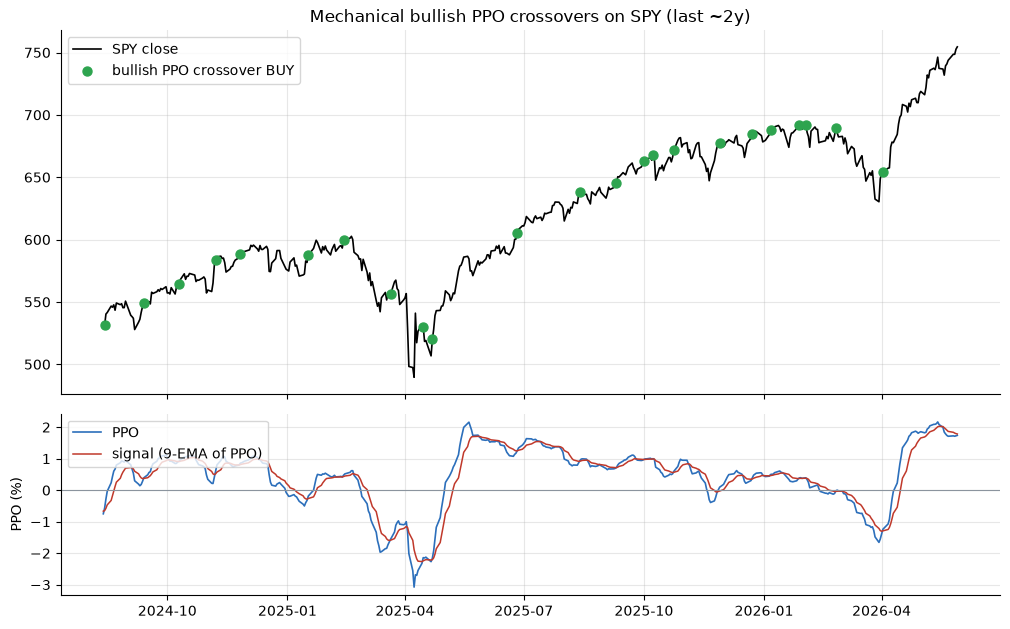

bullish crossovers in window: 23


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']
    ppo, sig = st.ppo_lines(cl)
    ent = st.ppo_cross_entries(cl)
    seg = cl.iloc[-450:]
    ent_w = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.4), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})
    ax1.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent_w, cl.reindex(ent_w), c=GREEN, s=42, zorder=5, label='bullish PPO crossover BUY')
    ax1.set_title('Mechanical bullish PPO crossovers on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg.index, ppo.reindex(seg.index), c='#2c6fbb', lw=1.2, label='PPO')
    ax2.plot(seg.index, sig.reindex(seg.index), c=RED, lw=1.1, label='signal (9-EMA of PPO)')
    ax2.axhline(0, c=GREY, lw=.8); ax2.set_ylabel('PPO (%)'); ax2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('bullish crossovers in window:', len(ent_w))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The crossover does what it says — it marks momentum turning up. The question is whether those green buy dots are *followed by* outperformance. **Let's race the crossover against random entries** at four horizons. Blue = buy the crossover; grey = buy on random days.

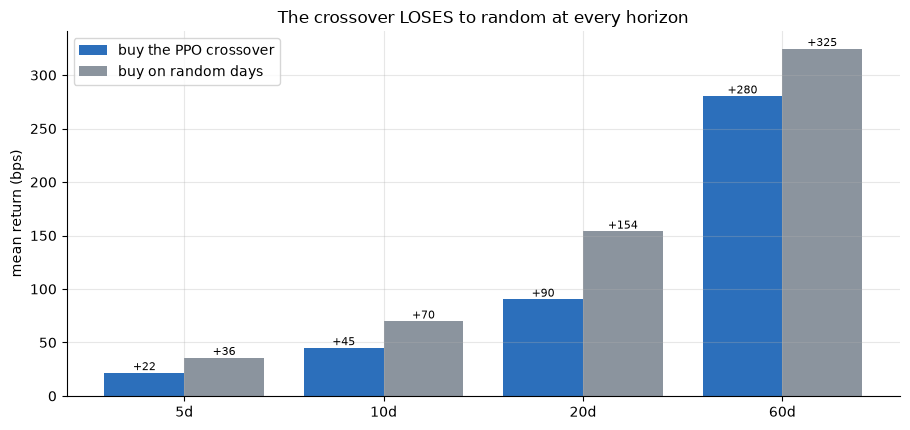

crossover: [22, 45, 90, 280]
random: [36, 70, 154, 325]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cross, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.ppo_cross_entries(c)
            re = st.random_entries(c, max(len(e), 50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        cross.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='buy the PPO crossover')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The crossover LOSES to random at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('crossover:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The crossover makes money in absolute terms (**+90 bps** over 20 days) — but **random entries make more** (**+154 bps**). At *every* horizon the famous crossover is *worse* than throwing darts, and at 20 days it's worse by a statistically meaningful margin (the quants notebook shows the Welch *t* hitting **−3.13** — "significant" in the wrong direction). The apparent edge was **the market's upward drift**, not the crossover.

**But does the normalization at least do *something*?** The PPO is just MACD divided by the slow EMA. Let's run the **raw MACD** crossover on the same tape and compare how each loses to random.

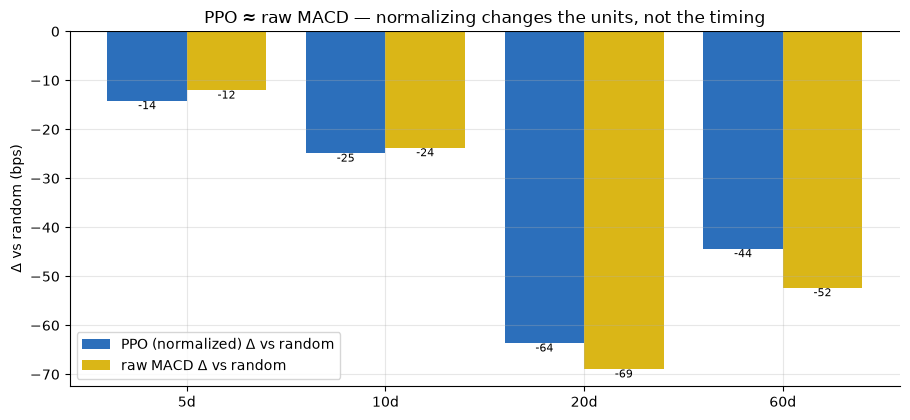

PPO  Δ: [-14, -25, -64, -44]
MACD Δ: [-12, -24, -69, -52]


In [4]:
if HAVE_REAL:
    ppo_d, macd_d = [], []
    for h in hs:
        pt, mt, rt = [], [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.ppo_cross_entries(c); me = st.macd_cross_entries(c)
            re = st.random_entries(c, max(len(e), 50), seed=7)
            pt.append(st.forward_returns(c, e, h)); mt.append(st.forward_returns(c, me, h))
            rt.append(st.forward_returns(c, re, h))
        r = np.concatenate(rt).mean()*1e4
        ppo_d.append(np.concatenate(pt).mean()*1e4 - r); macd_d.append(np.concatenate(mt).mean()*1e4 - r)
else:
    ppo_d = [m[1] for m in R['macd']]; macd_d = [m[2] for m in R['macd']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, ppo_d, .4, color='#2c6fbb', label='PPO (normalized) Δ vs random')
ax.bar(x+.2, macd_d, .4, color=AMBER, label='raw MACD Δ vs random')
ax.axhline(0, c='k', lw=.8)
for i,(a,bb) in enumerate(zip(ppo_d,macd_d)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('Δ vs random (bps)')
ax.set_title('PPO ≈ raw MACD — normalizing changes the units, not the timing'); ax.legend()
plt.tight_layout(); plt.show()
print('PPO  Δ:', [round(v) for v in ppo_d]); print('MACD Δ:', [round(v) for v in macd_d])

The two bars are essentially the same height at every horizon — both lose to random by the same margin. Dividing by the slow EMA barely moves *where* the lines cross, so the normalized PPO and the raw MACD fire on almost the same days and earn almost the same (negative-vs-random) returns. The percent sign buys **comparability across instruments**, not **edge**.

## 5 · The verdict

- **Signal — None.** The bullish PPO crossover does **not** beat buying on random days (it's *worse* at every horizon, significantly so at 20 days, Welch *t* = −3.13). The big absolute returns are the market's drift, not the crossover.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does normalizing MACD add edge?"— Busted.** The raw MACD crossover loses to random by the same margin, and scrambling the crossover's sign structure leaves the result intact. The percent sign changes units, not timing.

## 6 · Could you actually trade it?

There's nothing here to trade. The crossover's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The PPO buy is a worse, more expensive way to be long: it trades only on crossovers and pays commission + spread on each, so costs push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a way to *read* momentum on a chart, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The bearish side / shorting.** We tested the long. The symmetric short on bearish crossovers fares no better — same drift confound, with the sign flipped against you.
- **Different parameters.** Try 5/35/5 or 8/17/9 — the result is robust: drift in, crossover out. Tuning the EMAs is exactly the kind of in-sample search that manufactures mirages.
- **A real positive control.** The quants notebook plants a *genuine* post-crossover continuation into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the crossover forecasts? Show the bullish PPO cross beating random entries at **t ≥ 2** on a real tape — then we'll talk.*